## Encoding
### Opdracht

Zoals aan het begin van de cursus besproken gaat het project over handgeschreven nummers herekennen op een MysteryDevice met de volgende eigenschappen:

- Input scherm waarmee een nieuwe plaatje als ndarray aangemaakt kan worden door de gebruiker.
- Zeer beperkt RAM (256 KB)
- Beperkte opslag (1 MB voor 
programma + model)
- Geen GPU
- Embedded python


In [87]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
import sys


In [88]:
(images, labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
def print_bytes_numpy(obj: any):
    """
    Print the amount of bytes used by an object
    """
    print(f"element size: {obj.nbytes * 8} bits")
    print(f"data structure size: {sys.getsizeof(obj) * 8} bits")

def print_size_builtin(obj: any):
    print(f"data structure size: {sys.getsizeof(obj) * 8} bits")

MysteryDevice opslaglimiet: 1 MB
Volledige MNIST dataset: 52 MB

Dus het opslaan van MNST voor training doeleinden zou niet werken. Maar in ons geval maakt het ook niet uit, want we kunnen onze AI methode op een PC trainen.

Echter, hebben we nog steeds een encoding van afbeeldingen nodig omdat de gebruiker wel een afbeelding invoert.

#### Hoe ziet de input eruit tijdens inference?

De gebruiker tekent op het touchscreen → dat moet naar 28×28 of een andere encoding worden gebracht.

#### Hoeveel RAM gebruikt die inputrepresentatie?

784 bytes (1 byte per pixel) -> heel laag
maar 32‑bits floats → 784 × 4 = 3 KB -> al een stuk hoger

Ontwerp een encoding van een MNIST plaatje die zo min mogelijk geheugen nodig heeft op het MysteryDevice om je Decision Tree uit de vorige opdracht te draaien op 1 sample. 

Mogelijk heb je al wat gedaan in de vorige stap, maar kijk of je het nog meer kan verbeteren.
Het moet:

- minder geheugen gebruiken
- minder rekenkracht nodig hebben
- toch informatie bewaren om cijfers te herkennen

Maak eventueel gebruik aan de volgende onderweren, maar ga vooral zelf experimenteren:
- binning
(“donker / medium / licht” → 3 waarden)

- binary thresholding
(zwart/wit → 1 bit per pixel)

- downscaling
(28×28 → 14×14 → 196 features)

- flattening
(784 → 784 vector)

- quantization
(8-bit → 4-bit → 2-bit per pixel)

- feature extraction
(bijv. “hoeveel inkt zit links/rechts/boven/onder?”)
- sparse encoding
(alleen niet‑nul pixels bewaren)

- Ga je normaliseren? Hoe?
- Ga je flattenen of 2D laten staan?
- Ga je binning toepassen op pixelwaarden?
- Ga je ordinale encoding toepassen op pixelintensiteiten?
- Ga je pixelwaarden reduceren (bijv. “donker, medium, licht”)?
- Ga je één pixel gebruiken, of alle 784?

**Ga ook een eigen “encoding” bedenken!**

## No Encoding

In [90]:
def no_encode(img):
    encoded = img  # vervang dit
    return encoded

In [91]:
print_bytes_numpy(no_encode(images[0]))

element size: 6272 bits
data structure size: 1024 bits


## Binning met bool
Er is geen effect op de grote.


In [92]:
def bin_encode(img):
    encoded = np.astype(img, "bool")
    return encoded

In [93]:
print_bytes_numpy(bin_encode(images[0]))

element size: 6272 bits
data structure size: 7296 bits


# Binair Binnen

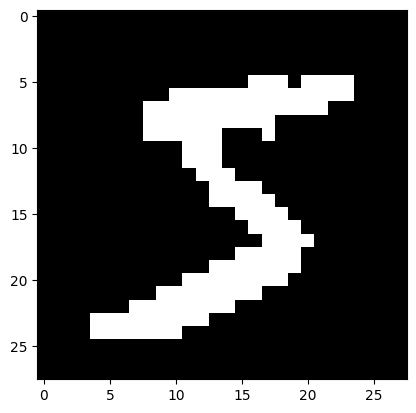

In [ ]:
def binary_encode(image):
    bin_image = bytearray()

    binary_secion: str = ""
    for row in image: # write pixel data one by one
        for pixel in row:
            if pixel > 50:
                binary_secion += "1"
            else:
                binary_secion += "0"

            if len(binary_secion)  == 8:
                encoded_section = int(binary_secion, 2)
                bin_image.append(encoded_section)
                binary_secion = ""

    return bytes(bin_image)

def binary_decode(binary: bytes):
    binaries = ""
    for byte in binary:
        binary_section = bin(byte)[2:].zfill(8)
        binaries += binary_section
    one_d_image = []
    for px in binaries:
        one_d_image.append(int(px) * 255)
    image = np.reshape(one_d_image, (28, 28))

    return image


encoded = binary_encode(images[0])
decoded = binary_decode(encoded)
plt.imshow(decoded, cmap="grey")
plt.show()

In [99]:
print_size_builtin(images[4])



data structure size: 1024 bits


Beantwoord ook de volgende vragen:

- Hoeveel RAM kost één afbeelding?
- Hoeveel RAM kost 100 afbeeldingen?
- Hoe groot zou het model maximaal mogen zijn?
- Kun je de encoding verder comprimeren?
- Is er informatie verloren gegaan?
- Kun je nog steeds het cijfer herkennen?